# 2026年の温度プロファイルと過去観測

**問い**：河口湖の等温に近い区間、函嶺洞門の勾配変化は再現するか。地質・地下水について何を言えて、何をまだ測る必要があるか。[実習で最低限行うこと](熱学実習_最低限の作業.md)を前提に、測定値と解釈を分ける。

2026年CSVの深度は、河口湖で**+0.85 m**、函嶺洞門で**+0.07 m**を加えた値を図と結果表に表示する。補正量は次のコードセルの `KAWAGUCHI_DEPTH_OFFSET_M`、`KANREI_DEPTH_OFFSET_M` で変更できる。河口湖32 mは空気中という現地情報に従い、水温比較は元の測点34 m以深（補正後34.85 m以深）だけを使う。33 mも共通基準に合わせて除外する。過去年の河口湖図も元の34 m未満を除く。過去データの深度は年ごとに小数の基準値を含むため、この**2026年用補正は重ねて適用しない**。年ごとの測定基準が完全にそろったわけではなく、細かな深度差を地層の移動と解釈しない。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

root = Path.cwd()
KAWAGUCHI_DEPTH_OFFSET_M = 0.85
KANREI_DEPTH_OFFSET_M = 0.07
current = {
    '河口湖': pd.read_csv(root/'2026_Kawaguchi.csv').query('Depth >= 34').copy(),
    '函嶺洞門': pd.read_csv(root/'2026_KanreiTunnel.csv').copy(),
}
for site, offset in [('河口湖', KAWAGUCHI_DEPTH_OFFSET_M),
                     ('函嶺洞門', KANREI_DEPTH_OFFSET_M)]:
    d = current[site]
    d['Depth_raw'] = d['Depth']
    d['Depth'] = d['Depth_raw'] + offset
    print(site, f'補正後 {d.Depth.min():.2f}–{d.Depth.max():.2f} m',
          '欠損', d[['Depth','Temperature']].isna().sum().sum())

河口湖 補正後 34.85–120.85 m 欠損 0
函嶺洞門 補正後 6.07–70.07 m 欠損 0


## 各年の曲線

2013–2019年の河口湖と2015–2023年の箱根は既存の過去プロファイル集を使う。2024年はサーミスタ記録、2025年は野帳から追加した。**2025年河口湖の換算温度は要検証**なので主図に重ねず、後の表と抵抗値照合で監査する。黒線のみ今回の深度補正後、他の年は各資料記載の深度である。凡例の年は観測年で、測定時期や機器条件は完全には一致しない。

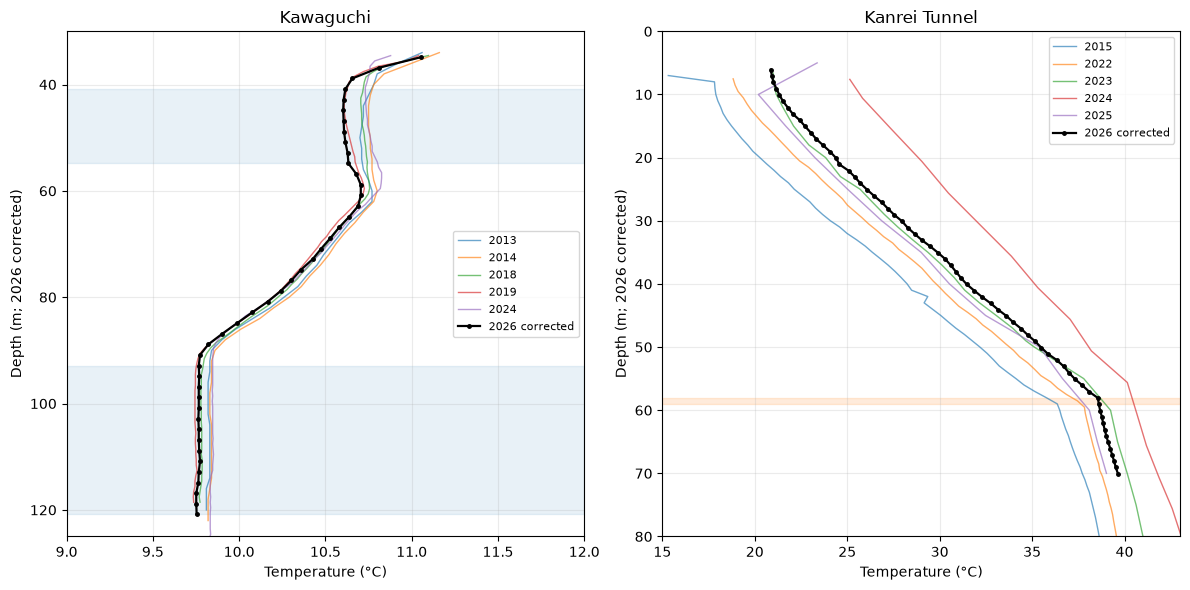

In [2]:
def two_columns(path, sheet, cols='A:B'):
    d = pd.read_excel(path, sheet_name=sheet, usecols=cols, header=None,
                      names=['Depth','Temperature'])
    return d.apply(pd.to_numeric, errors='coerce').dropna()

past = {}
kfile = root/'history/河口湖過去データ/ホテルレジーナ温度プロファイル.xlsx'
hfile = root/'history/箱根過去データ/箱根温度プロファイル 全部入り.xlsx'
for year in ('2013','2014','2018','2019'):
    past[('河口湖',year)] = two_columns(kfile,year).query('Depth >= 34')
for year,sheet in [('2015','20151206'),('2022','20220728'),('2023','Sheet1')]:
    past[('函嶺洞門',year)] = two_columns(hfile,sheet)
file24 = root/'history/2024箱根河口湖サーミスタ記録.xlsx'
past[('河口湖','2024')] = two_columns(file24,'河口湖セルシウスデータ').query('Depth >= 34')
past[('函嶺洞門','2024')] = two_columns(file24,'箱根湯本セルシウスデータ')
file25 = root/'history/野帳2025.xlsx'
past[('河口湖','2025*')] = two_columns(file25,'2025Regina','D,G').query('Depth >= 34')
past[('函嶺洞門','2025')] = two_columns(file25,'2025Hakone','D,G')

fig, axes = plt.subplots(1,2,figsize=(12,6))
for ax,site in zip(axes,current):
    for (place,year),d in past.items():
        if place==site and '*' not in year:
            ax.plot(d.Temperature,d.Depth,lw=1,alpha=.65,label=year)
    d=current[site]
    ax.plot(d.Temperature,d.Depth,'ko-',ms=2.5,lw=1.6,label='2026 corrected')
    if site == '河口湖':
        for lo, hi in [(40,54),(92,120)]:
            ax.axhspan(lo+KAWAGUCHI_DEPTH_OFFSET_M, hi+KAWAGUCHI_DEPTH_OFFSET_M,
                       color='tab:blue',alpha=.10)
    else:
        ax.axhspan(58+KANREI_DEPTH_OFFSET_M,59+KANREI_DEPTH_OFFSET_M,
                   color='tab:orange',alpha=.15)
    ax.set(title={'河口湖':'Kawaguchi','函嶺洞門':'Kanrei Tunnel'}[site],
           xlabel='Temperature (°C)',ylabel='Depth (m; 2026 corrected)')
    ax.invert_yaxis();ax.grid(alpha=.25);ax.legend(fontsize=8)
axes[0].set(ylim=(125,30),xlim=(9,12));axes[1].set(ylim=(80,0),xlim=(15,43))
plt.tight_layout();plt.show()

In [3]:
# 特徴区間は元の測点で指定し、表示・集計は補正後深度に統一
features = []
for site, label, lo, hi in [
    ('河口湖','上側のほぼ等温区間',40,54),
    ('河口湖','深部のほぼ等温区間',92,120),
    ('函嶺洞門','勾配の折れ目',58,59),
    ('函嶺洞門','折れ目より下の緩勾配',59,70),
]:
    d = current[site].query('@lo <= Depth_raw <= @hi')
    features.append([site,label,f'{d.Depth.min():.2f}–{d.Depth.max():.2f}',
                     d.Temperature.mean(),d.Temperature.min(),
                     d.Temperature.max(),d.Temperature.max()-d.Temperature.min()])
feature_table = pd.DataFrame(features,columns=['地点','特徴','補正後深度 m',
                                               '平均 °C','最低 °C','最高 °C','温度幅 °C'])
display(feature_table.round(3))

,地点,特徴,補正後深度 m,平均 °C,最低 °C,最高 °C,温度幅 °C
0,河口湖,上側のほぼ等温区間,40.85–54.85,10.614,10.603,10.633,0.031
1,河口湖,深部のほぼ等温区間,92.85–120.85,9.764,9.751,9.773,0.022
2,函嶺洞門,勾配の折れ目,58.07–59.07,38.585,38.563,38.607,0.044
3,函嶺洞門,折れ目より下の緩勾配,59.07–70.07,39.094,38.607,39.645,1.039


河口湖の**40.85–54.85 m**は約**10.61 °C**（幅約**0.031 °C**）、**92.85–120.85 m**は約**9.76 °C**（幅約**0.022 °C**）で、ほぼ等温である。函嶺洞門は等温区間ではなく、**58.07–59.07 m**で約**38.56–38.61 °C**を通るところに勾配の折れ目がある。59.07–70.07 mは温度が約38.61–39.65 °Cに上がり続けるため「一定」と呼ばない。陰影はこの区間を図上に示す。境界の端点は選んだ測点であり、流入点・地層境界の確定値ではない。

## 固定区間の勾配を比較する

区間は2026年の**元の測点番号**で選び、過去年にはその数値の範囲を資料記載の深度に適用する。2026年の表には補正後の区間も併記する。一定の深度加算は回帰勾配を変えない。直線回帰は曲線の**区間平均勾配**を表すだけで、点列の散らばりから機器校正・深度基準・流れによる系統誤差は評価できない。過去データは点の間隔も異なる。河口湖の `2025*` は温度換算が要検証という印で、有効な年比較には入れない。過去年の一部は少数の測点による回帰なので、勾配は形の参考にとどめる。

In [4]:
zones = {'河口湖':[(36,58),(60,88),(92,120)],
         '函嶺洞門':[(20,58),(59,70)]}
rows=[]
for (site,year),d in list(past.items())+[((s,'2026'),d) for s,d in current.items()]:
    for lo,hi in zones[site]:
        depth_for_selection = d.Depth_raw if year == '2026' else d.Depth
        part = d[(depth_for_selection >= lo) & (depth_for_selection <= hi)]
        if len(part)>=3:
            f=linregress(part.Depth,part.Temperature)
            offset = {'河口湖':KAWAGUCHI_DEPTH_OFFSET_M,
                      '函嶺洞門':KANREI_DEPTH_OFFSET_M}[site] if year == '2026' else 0
            shown = f'{lo+offset:.2f}–{hi+offset:.2f}' if year == '2026' else f'{lo}–{hi}'
            rows.append([site,year,f'{lo}–{hi}',shown,f.slope,
                         part.Temperature.max()-part.Temperature.min()])
slopes=pd.DataFrame(rows,columns=['地点','年','元区間 m','表示区間 m','勾配 °C/m','温度幅 °C'])
display(slopes.round({'勾配 °C/m':4,'温度幅 °C':3}))

,地点,年,元区間 m,表示区間 m,勾配 °C/m,温度幅 °C
0,河口湖,2013,36–58,36–58,-0.0059,0.220
1,河口湖,2013,60–88,60–88,-0.0309,0.870
2,河口湖,2013,92–120,92–120,-0.0004,0.020
3,河口湖,2014,36–58,36–58,-0.0054,0.250
4,河口湖,2014,60–88,60–88,-0.0306,0.880
5,河口湖,2014,92–120,92–120,-0.0004,0.020
6,河口湖,2018,36–58,36–58,-0.0007,0.138
7,河口湖,2018,60–88,60–88,-0.0301,0.838
8,河口湖,2018,92–120,92–120,-0.0002,0.024
9,河口湖,2019,36–58,36–58,0.0000,0.197


**数値の読み方**：河口湖2026年の補正後36.85–58.85 mは約 −0.0012 °C/m（温度幅0.207 °C）、60.85–88.85 mは約 −0.0319 °C/m、92.85–120.85 mは約 −0.0004 °C/m（温度幅0.022 °C）。2013・2014・2018・2019・2024年でも元の60–88 m帯は約 −0.0300～−0.0329 °C/m、深部はほぼ水平で、低勾配と中間の下降が単年の読み間違いとは考えにくい。ただし資料ごとの深度基準差は残る。

函嶺洞門2026年の補正後20.07–58.07 mは約 +0.375 °C/m、59.07–70.07 mは約 +0.095 °C/mで約4分の1に低下。2015・2022・2023・2025年にも元の約60 m前後の折れ目がある。2024年はこの深さで点が少なく、下側の独立した回帰はしない。勾配差の反復は岩相変化を疑う根拠になるが、同じ形は井戸内の流動や含水率変化でも生じ得る。

In [5]:
# 2026年を単一直線と固定した3区間／2区間の直線で記述したときの残差
fit_rows = []
for site, start, sections in [
    ('河口湖',34,[(34,58),(60,88),(90,120)]),
    ('函嶺洞門',20,[(20,58),(59,70)]),
]:
    d = current[site].query('Depth_raw >= @start')
    x, y = d.Depth.to_numpy(), d.Temperature.to_numpy()
    one_line = np.polyval(np.polyfit(x,y,1),x)
    piecewise = np.empty_like(y)
    for lo,hi in sections:
        use = d.Depth_raw.between(lo,hi).to_numpy()
        piecewise[use] = np.polyval(np.polyfit(x[use],y[use],1),x[use])
    fit_rows.append([site,np.sqrt(np.mean((y-one_line)**2)),
                     np.sqrt(np.mean((y-piecewise)**2))])
display(pd.DataFrame(fit_rows,columns=['地点','単一直線RMSE °C','区間直線RMSE °C']).round(3))

,地点,単一直線RMSE °C,区間直線RMSE °C
0,河口湖,0.142,0.062
1,函嶺洞門,0.660,0.080


### 非線形性を数値で確認する

直線の温度プロファイルなら、区間勾配は概ね同じになる。しかし河口湖2026年は補正後36.85–58.85 mで−0.0012 °C/m、60.85–88.85 mで−0.0319 °C/m、92.85–120.85 mで−0.0004 °C/mと明確に異なる。中間の下降区間を挟み、上側40.85–54.85 mは10.603–10.633 °C、深部92.85–120.85 mは9.751–9.773 °Cに集中する。函嶺洞門も20.07–58.07 mの+0.375 °C/mに対し、59.07–70.07 mは+0.095 °C/mで、約59 m付近に勾配の折れ目がある。

上表の全域への単一直線と固定区間の直線を同じ2026年データに当てはめると、RMSEは河口湖0.142→0.062 °C、函嶺洞門0.660→0.080 °Cとなる。区間を増やせば誤差が減るのは当然であり、これは**単一直線では形を表しきれないことの記述的確認**であって、区間数の最適性や境界深度の信頼区間を示す検定ではない。観測点は離散的なので、数学的な「変曲点」（曲率の符号が変わる点）を特定したとは言わず、**勾配の折れ目／遷移帯**と呼ぶ。

In [6]:
# 2025年河口湖の温度換算を、ほぼ同じ抵抗値を持つ2026年と照合
check25 = pd.read_excel(file25,sheet_name='2025Regina',usecols='D,E,G',header=None,
                        names=['Depth','R_kohm','Temperature']).apply(pd.to_numeric,errors='coerce').dropna()
check = check25[check25.Depth.isin([40,100])].merge(
    current['河口湖'][['Depth_raw','Measured resistance','Temperature']].rename(columns={'Depth_raw':'Depth'}),on='Depth',suffixes=('_2025','_2026'))
display(check.round(3))

,Depth,R_kohm,Temperature_2025,Measured resistance,Temperature_2026
0,40.0,9.493,17.949,9.517,10.616
1,100.0,9.859,17.077,9.858,9.766


2025年河口湖は40 mで抵抗値9.493 kΩ・換算17.949 °C、2026年の同じ元測点40 m（補正後40.85 m）は9.517 kΩ・10.616 °C。近い抵抗値から約7.3 °C違う換算温度が得られている。地下水温の年変動として扱う前に、2025年野帳の換算式・係数・参照セルを原本で確認する必要がある。2025年の曲線形状は参考になるが、絶対温度と勾配を有効値の根拠に使わない。

## 地質・水理の背景と観測との対応

| 地点 | 地域の根拠 | 温度形との関係と限界 |
|---|---|---|
| 河口湖・ホテルレジーナ脇 | [現地地図 p.3](2026実習地図など.pdf)は河口湖南岸の井戸を示す。[富士山科学研究所の南岸地下水論文](https://www.mfri.pref.yamanashi.jp/mfr/pdf/no11/2017-p1-p9.pdf)は南岸の大半が富士山由来の溶岩に覆われ、溶岩と火山砂礫の互層が帯水層をつくると述べる。[産総研の富士火山地質図](https://gbank.gsj.jp/volcano/Act_Vol/fujisan/text/exp-2.html)は富士山に玄武岩質噴出物が広くあることを示す。[河口湖の湖底湧水研究](https://www.jstage.jst.go.jp/article/jgeography/129/5/129_129.665/_article/-char/ja/)は地下水と湖水の関係を実証する。[北麓の地下水総説](https://www.jstage.jst.go.jp/article/jgeography/129/5/129_129.677/_article/-char/ja/)は緻密な溶岩部と節理・クリンカーなどで透水性が異なると説明する。 | 40.85–54.85 mの10.61 °C付近、92.85–120.85 mの9.76 °C付近という等温に近い区間は、地下水の流入・井戸内流動で温度が均されるという解釈と整合する。[USGSの温度検層解説](https://www.usgs.gov/media/images/geophysical-logs-temperature-logs)も低勾配を孔内流動・帯水部を調べる手掛かりとしている。高透水部が流入経路の候補だが、この井戸の各深度が玄武岩溶岩か火山砂礫か、どの高さが開口部かは柱状図なしには不明。北・東岸には御坂山地の岩石もあり、河口湖全域を玄武岩だけとしない。 |
| 函嶺洞門脇 | [温泉地学研究所の解説](https://www.onken.odawara.kanagawa.jp/hotspring/onsen_kouza/20200519-01.html)は湯本・塔之沢の温泉が早川凝灰角礫岩など基盤岩に関わるとする。[同研究所の湯本・塔之沢地質研究](https://www.onken.odawara.kanagawa.jp/files/PDF/houkoku/03/houkoku03-9.pdf)は凝灰角礫岩・火山礫凝灰岩・軽石凝灰岩、須雲川安山岩類、割れ目系を記載する。 | 補正後約58.07–59.07 mの折れ目と下側の勾配低下は、岩相・含水率・割れ目密度・熱伝導率の変化で起こり得る。井戸内の水の流入や混合でも同様の折れ目になる。函嶺洞門の井戸を「玄武岩質の土壌」と決めたり、折れ目を凝灰角礫岩と別岩層の境界と名付けたりはできない。 |

河口湖では地下水、函嶺洞門では岩相・熱物性・水流が数値と地質資料の双方に照らして有力な候補である。函嶺洞門の折れ目を岩相だけで説明するには、岩石の熱物性を測って比較する必要がある。割れ目沿いの水流も同じ形をつくり得る。温度検層だけでは弱い温泉脈を見逃すこともある（[温泉地学研究所の検層解説](https://www.onken.odawara.kanagawa.jp/hotspring/onsen_kouza/20200522-03.html)）。

### 過去との照合から何が強まるか

- **河口湖**：2013・2014・2018・2019・2024年の元60–88 m帯は−0.0300～−0.0329 °C/mで、2026年の−0.0319 °C/mと近い。深部92–120 m帯も過去年の−0.0002～−0.0005 °C/mと2026年の−0.0004 °C/mが近い。一方、上側36–58 m帯は過去−0.0059～+0.0036 °C/mと年差があり、2026年の狭い等温区間40.85–54.85 mが全ての年に同じ幅・同じ絶対温度で存在したとは主張しない。2025年の抵抗値→温度換算には不整合があるため、同年の温度を年差の証拠に含めない。
- **函嶺洞門**：2015・2022・2023・2025年の元20–58 m帯は+0.385～+0.399 °C/m、59–70 m帯は+0.086～+0.122 °C/mであり、2026年の+0.375/+0.095 °C/mと勾配の大小関係が一致する。2024年は下側の測点不足で比較できない。[過去の箱根実習ポスター p.1](history/箱根過去データ/観測実習ポスター.pdf)も約60 mまで、60–80 m、80 m以深で勾配が異なると記す。繰り返す形は一時的な読み誤りより、井戸または周囲の安定した構造を示唆する。ただし年ごとの深度基準、季節、揚水条件と校正がそろっていないため、折れ目が**同じ数十cmの位置に固定**されたとは言えない。

### 非線形性の原因：岩質と地下水をどう比較するか

河口湖南岸の[浅層地下水研究 pp.1–2, 5](reference/河口湖/MFR_No11_p1_p9.pdf)は、溶岩と火山砂礫の互層を記し、湖岸近くと内陸寄りの古井戸で水の起源が異なり得ることを同位体で示す。[富士北麓の水文地質研究 pp.1, 21–23](reference/河口湖/Uchyama_129_129.697.pdf)は緻密な溶岩と節理・クリンカーの透水性の差、河口湖南岸への湖水流出を述べる。このため、2026年の低勾配は透水部を通る水の流入・井戸内流動で温度が均されたという仮説に合う。[USGSの温度検層資料](https://www.usgs.gov/media/images/geophysical-logs-temperature-logs)も帯水部や孔内流動を低勾配から探る方法を説明する。ただし**この井戸への水の流れの向き**は温度だけでは分からず、北岸の[湖底湧水研究 p.1](reference/河口湖/129_129.665.pdf)で報告された約11.3 °Cの湧水（主に御坂山地由来）を、南岸の本井戸の10.61 °C帯と同一水源とはみなせない。岩質変化だけでも熱伝導率・透水性の差が温度形に影響し得る。

函嶺洞門では[温泉地学研究所の湯本・塔之沢解説](https://www.onken.odawara.kanagawa.jp/hotspring/onsen_kouza/20200519-01.html)と[周辺地質の研究](reference/箱根/houkoku03-9早川凝灰角礫岩.pdf)が早川凝灰角礫岩などの基盤岩、安山岩類、割れ目と温泉の関係を述べる。59 m付近の折れ目が複数年に現れるので、岩相・熱物性・割れ目密度の変化という仮説には根拠がある。同時に、温泉水と浅い地下水の混合や孔内の縦流れでも勾配は変わり得る。**岩質境界なら**柱状図・孔壁画像・熱伝導率の変化が同じ深度に現れるはずで、**流入・混合なら**流速・電気伝導度・水温の反復検層に対応が現れるはずである。両者は共存もあり得る。

## 次の観測で求めたい値

| 求めたい値・判別したいこと | 入手すべきデータ |
|---|---|
| 河口湖の流入深度・流量と流れの向き | 同じ井戸のケーシング／スクリーン図、深度別流速・流向検層、温度・電気伝導度の昇降時反復検層、井戸内外の水位差 |
| 玄武岩質溶岩・火山砂礫・他層の正確な深度 | 両井戸の掘削柱状図、コア・カッティングの岩石記載、孔内画像と物理検層 |
| 函嶺洞門の折れ目が岩相差か水の流入か | 補正後約50.07–75.07 mを細かく測る柱状図、岩石の熱伝導率、深度別流速・電気伝導度・水温の反復測定 |
| 年差が本当の温度変化か | 同一基準での深度補正、測定時の水位・揚水履歴、機器校正記録、2025年の抵抗値→温度換算式 |

これらが揃うまで、勾配と再現する形を観測結果とし、地下水流入と岩相変化は検証すべき仮説として報告する。